complexity_bin
med     3533
low     1890
high     459
Name: count, dtype: int64
complexity_bin
med     1310
low      683
high     236
Name: count, dtype: int64
complexity_bin
med     2223
low     1207
high     223
Name: count, dtype: int64
 Bin Range           Metric  Human_Med  Agent_Med  Human_mean  Agent_mean  p-value  rank_biserial     Effect
 low   0-0       doc_tokens     11.000      7.000      25.691      14.506 1.57e-09         -0.167      Small
 low   0-0      doc_entropy      3.278      2.750       3.143       2.754 9.46e-12         -0.188      Small
 low   0-0 doc_code_overlap      0.130      0.286       0.170       0.303 3.33e-33          0.329      Small
 low   0-0   doc_redundancy      0.000      0.000       0.114       0.106 1.34e-01         -0.038 Negligible
 med   1-3       doc_tokens     12.000     13.000      39.008      18.368 2.77e-06         -0.094 Negligible
 med   1-3      doc_entropy      3.459      3.323       3.536       3.247 2.25e-08         -0.112 Negligib

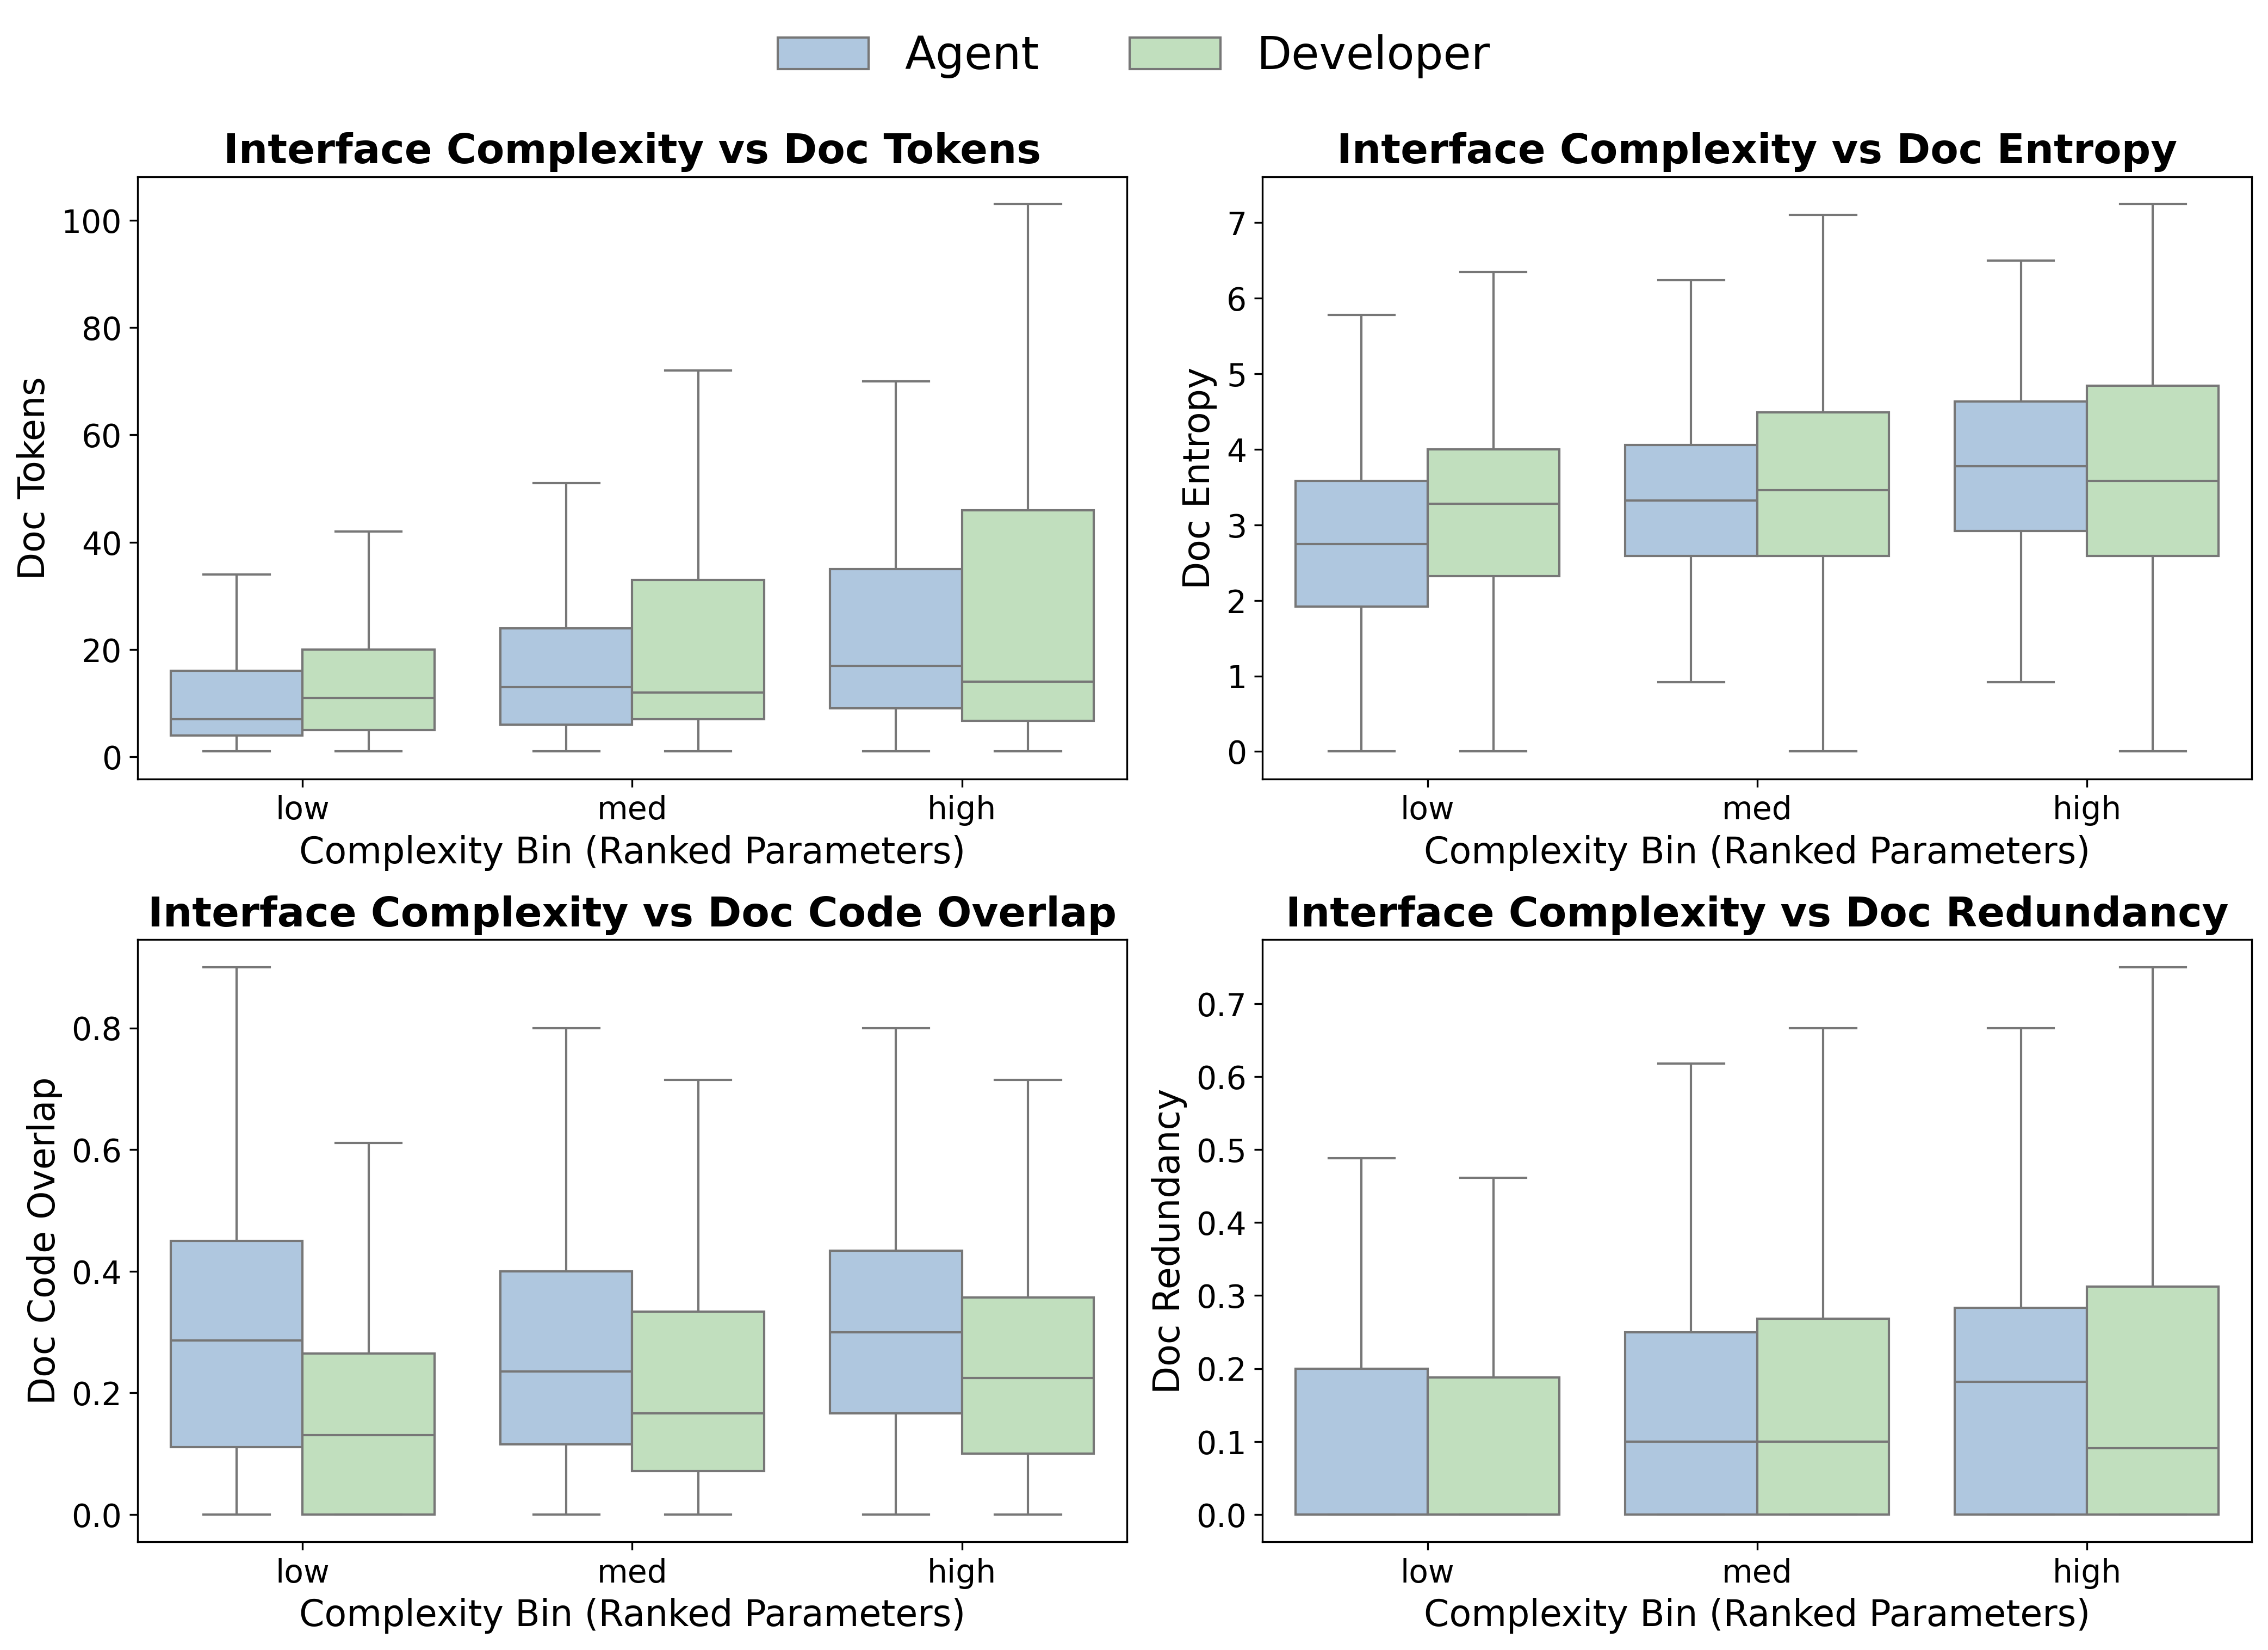

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu
import re
def tokenize(text): #this tokenizer will split words based on the aplabetical content, 
    if not isinstance(text, str): # "def tokenize(text): boom1 bang" -> print(tokenize("def tokenize(text): boom1 bang"))
        return []
    return re.findall(r"[A-Za-z_][A-Za-z0-9_]*", text.lower())


def calculate_rank_biserial(group_h, group_a):
    """
    Calculates the Rank-Biserial Correlation (r_rb).
    r_rb = 1 - (2 * U) / (n1 * n2)
    Where U is the Mann-Whitney U statistic for the human group.
    """
    n1 = len(group_h)
    n2 = len(group_a)
    
    if n1 == 0 or n2 == 0:
        return 0
        
    # stat is the U-statistic for the first argument (group_h)
    stat, p = mannwhitneyu(group_h, group_a, alternative='two-sided')
    
    # This formula gives:
    # Positive value: Agent values are generally higher than Human
    # Negative value: Human values are generally higher than Agent
    r_rb = 1 - (2 * stat) / (n1 * n2)
    return r_rb

def get_delta_label(d):
    """Standard interpretation thresholds for Cliff's Delta (Romano et al. 2006)."""
    ad = abs(d)
    if ad < 0.147: return "Negligible"
    if ad < 0.330: return "Small"
    if ad < 0.474: return "Medium"
    return "Large"

# 1. Load and Clean Data
# df = pd.read_csv(r"G:\663P\dataset\data\updated_dataset_metrics.csv")
# df = pd.read_csv(r"/Volumes/T7-Shield/663P/dataset/data/updated_dataset_metrics.csv")
df = pd.read_csv(r"G:\663P\dataset\data\updated_dataset_2_metrics_f.csv")
df = df.dropna(subset=["doc_entropy", "doc_code_overlap", "doc_redundancy"])


# 2. Apply your specific ranking-based binning
# We bin the entire dataset so 'high' complexity refers to the same threshold for both groups
bins = [0, 1, 4, df["num_parameters"].max()]
labels = ["low", "med", "high"]

df["complexity_bin"] = pd.cut(
    df["num_parameters"],
    bins=bins,
    labels=labels,
    include_lowest=True,
    right=False
)
print(df["complexity_bin"].value_counts())
h_vals = df[df['group'] == 'human']
a_vals = df[df['group'] == 'agent']
print(h_vals["complexity_bin"].value_counts())
print(a_vals["complexity_bin"].value_counts())


metrics = ['doc_tokens', 'doc_entropy', 'doc_code_overlap', 'doc_redundancy']
bin_labels = ["low", "med","high"]

df["doc_tokens"] = df["doc_text"].apply(lambda x: len(tokenize(x)))
# 3. Comparative Analysis Loop
results = []
for b in bin_labels:
    b_df = df[df['complexity_bin'] == b]
    h_vals = b_df[b_df['group'] == 'human']
    a_vals = b_df[b_df['group'] == 'agent']
    
    # Calculate min/max parameters in this bin for context
    p_min = b_df['num_parameters'].min()
    p_max = b_df['num_parameters'].max()
    
    for m in metrics:
        stat, p = mannwhitneyu(h_vals[m], a_vals[m], alternative='two-sided')
        d = calculate_rank_biserial(h_vals[m], a_vals[m])
        
        results.append({
            'Bin': b,
            'Range': f"{p_min}-{p_max}",
            'Metric': m,
            'Human_Med': round(h_vals[m].median(), 3),
            'Agent_Med': round(a_vals[m].median(), 3),
            'Human_mean': round(h_vals[m].mean(), 3),
            'Agent_mean': round(a_vals[m].mean(), 3),
            'p-value': f"{p:.2e}",
            'rank_biserial': round(d, 3),
            'Effect': get_delta_label(d)
        })

# 4. Output results
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))
df["group"] = df["group"].replace({
    "agent": "Agent",
    "human": "Developer"
})
# 5. Visualization# 5. Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10), dpi=300)
axes = axes.flatten()

for i, m in enumerate(metrics):
    ax = axes[i]
    
    sns.boxplot(
        data=df,
        x='complexity_bin',
        y=m,
        hue='group',
        order=bin_labels,
        showfliers=False,
        palette={"Agent": "#A7C7E7", "Developer": "#BDE5B8"},
        ax=ax
    )
    
    ax.set_title(
        f'Interface Complexity vs {m.replace("_", " ").title()}',
        fontsize=18,
        fontweight='bold'
    )
    
    ax.set_xlabel('Complexity Bin (Ranked Parameters)', fontsize=16)
    ax.set_ylabel(m.replace("_", " ").title(), fontsize=16)

    ax.tick_params(axis='x', labelsize=14)
    ax.tick_params(axis='y', labelsize=14)

    # ❌ REMOVE per-plot legends
    ax.get_legend().remove()

# 🔥 Create ONE shared legend at top
# remove per-axis legends
for ax in axes:
    if ax.get_legend() is not None:
        ax.get_legend().remove()

# shared legend (tighter placement)
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc='upper center',
    ncol=2,
    bbox_to_anchor=(0.5, 1.02),
    fontsize=20,
    title="",
    title_fontsize=14,
    frameon=False
)

plt.tight_layout(rect=[0, 0, 1, 0.93])

plt.tight_layout(rect=[0, 0, 1, 0.95])  # leave space for legend
plt.savefig('rq3_ranked_complexity.png', dpi=300, bbox_inches='tight')
plt.show()

In [11]:
# -------------------------------
# 6. Quantile Regression (PER GROUP)
# -------------------------------

import statsmodels.api as sm

quantiles = [0.5, 0.75, 0.9]
qr_results = []

for g in ["Developer", "Agent"]:
    sub = df[df["group"] == g]
    
    for q in quantiles:
        model = sm.QuantReg(
            np.log1p(sub["doc_tokens"]),
            sm.add_constant(sub["num_parameters"])
        ).fit(q=q)
        
        slope = model.params["num_parameters"]
        pval = model.pvalues["num_parameters"]
        
        qr_results.append({
            "Group": g,
            "Quantile": q,
            "Slope": round(slope, 4),
            "p-value": f"{pval:.2e}"
        })

qr_df = pd.DataFrame(qr_results)

print("\nQuantile Regression (per group):")
print(qr_df.to_string(index=False))


Quantile Regression (per group):
    Group  Quantile  Slope  p-value
Developer      0.50 0.0000 1.00e+00
Developer      0.75 0.1238 2.63e-18
Developer      0.90 0.1002 1.93e-10
    Agent      0.50 0.1714 5.23e-30
    Agent      0.75 0.1322 2.02e-24
    Agent      0.90 0.0936 1.51e-09
